In [1]:
### 다층 RNN을 구현하기전 데이터 준비

import pyprind
import pandas as pd
from string import punctuation
import re
import numpy as np

df = pd.read_csv("movie_data.csv", encoding='utf-8')
print(df.head(3))

                                              review  sentiment
0  In 1974, the teenager Martha Moxley (Maggie Gr...          1
1  OK... so... I really like Kris Kristofferson a...          0
2  ***SPOILER*** Do not read this, if you think a...          0


In [2]:
### 데이터 전처리

from collections import Counter

# 단어를 나누고 등장 횟수를 카운트하는 전처리
counts = Counter()
pbar = pyprind.ProgBar(len(df['review']), title='단어 등장 횟수 카운트')

for i,review in enumerate(df['review']):
    text = ''.join([c if c not in punctuation else ' '+c+' ' \
                    for c in review]).lower()
    df.loc[i,'review'] = text
    pbar.update()
    counts.update(text.split())

# 고유한 각 단어를 정수로 매핑하는 딕셔너리 만들기

word_counts = sorted(counts, key=counts.get, reverse=True)
print(word_counts[:5])
word_to_int = {word : ii for ii, word in enumerate(word_counts, 1)}

mapped_reviews = []
pbar = pyprind.ProgBar(len(df['review']), title='리뷰를 정수로 매핑')

for review in df['review']:
    mapped_reviews.append([word_to_int[word] for word in review.split()])
    pbar.update()



단어 등장 횟수 카운트
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:08
리뷰를 정수로 매핑


['the', '.', ',', 'and', 'a']


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


In [3]:
### 데이터 전처리 2 (동일 길이의 시퀀스로 만들어주기)


# 문장들의 길이가 전부 제각각이기 때문에 길이 200개인 시퀀스로 만들어주는데,
# 문장의 오른쪽 끝 단어부터 시퀀스에 매핑함
# 결국에 200보다 긴 단어라면 왼쪽에 있는 단어(문장 초반부)가 잘리게 됨.
# 물론 200보다 짧다면 기본적으로 시퀀스는 0으로 초기화 하기 때문에 남은 부분은 0으로 매핑됨.
 
sequence_length = 200

sequences = np.zeros((len(mapped_reviews), sequence_length), dtype=int)

for i, row in enumerate(mapped_reviews):
    review_arr = np.array(row)
    sequences[i, -len(row):] = review_arr[-sequence_length:]
    
X_train = sequences[:37500, :]
y_train = df.loc[:37499, 'sentiment'].values
X_test = sequences[37500:, :]
y_test = df.loc[37500:, 'sentiment'].values

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


(37500, 200) (37500,) (12500, 200) (12500,)


In [ ]:
### 단어 임베딩

# 단순히 원-핫 인코딩으로 단어사전을 만들면 특성 차원이 너무 커져서
# 훈련할때 차원의 저주 효과가 나타날 수 있음.
# 그렇기에 -1~1 사이의 실수값을 이용하는 아이디어로 해결함.
# 텐서플로에는 자동으로 단어를 임베딩해주는 tf.keras.layers.Embedding 클래스가 구현되어있음.

from keras import models, layers

n_words = len(word_to_int) + 1

model = models.Sequential()
model.add(layers.Embedding(input_dim=n_words, output_dim=200, embeddings_regularizer='l2', input_shape=(100,)))

model.summary()

In [ ]:
### 본격적인 RNN 모델 만들기

model.add(layers.LSTM(16))
model.add(layers.Flatten())
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

In [9]:
### 모델 컴파일

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

In [10]:
### 모델 훈련해보기

history = model.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=0.3)


Epoch 1/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - acc: 0.7304 - loss: 6.5171 - val_acc: 0.8191 - val_loss: 0.6250
Epoch 2/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 42s 102ms/step - acc: 0.8333 - loss: 0.5974 - val_acc: 0.8440 - val_loss: 0.5901
Epoch 3/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - acc: 0.8523 - loss: 0.5386 - val_acc: 0.7931 - val_loss: 0.6403
Epoch 4/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - acc: 0.8577 - loss: 0.5132 - val_acc: 0.8655 - val_loss: 0.4747
Epoch 5/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - acc: 0.8693 - loss: 0.4882 - val_acc: 0.8084 - val_loss: 0.5843
Epoch 6/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - acc: 0.8748 - loss: 0.4734 - val_acc: 0.8720 - val_loss: 0.4763
Epoch 7/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 159s 388ms/step - acc: 0.8815 - loss: 0.4610 - val_acc: 0.8720 - val_loss: 0.4894
Epoch 8/10
411/411 ━━━━━━━━━━━━━━━━━━━━ 223s 438ms/step - acc: 0.8855 - loss: 0.4456 - val_acc: 0.8658 - val_loss: 0.4841
Epoch 9/10
411/411 ━━━━━━━━━━━

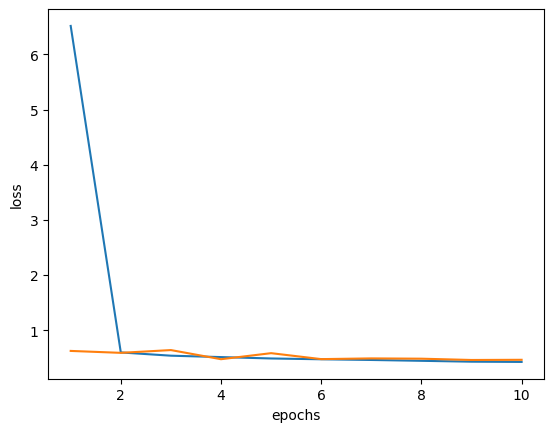

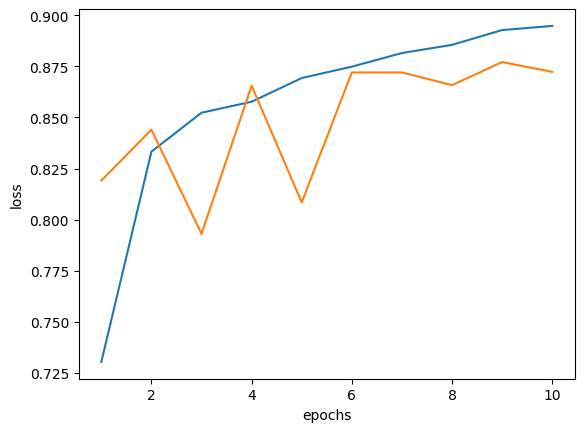

In [ ]:
### 손실 그래프와 정확도 그래프 그려보기

import matplotlib.pyplot as plt

# 손실 그래프
epochs = np.arange(1, 11)
plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

# 정확도 그래프
epochs = np.arange(1, 11)
plt.plot(epochs, history.history['acc'])
plt.plot(epochs, history.history['val_acc'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

# 결과를 보면 2 epoch만에 로스는 확 떨어졌지만, 정확도 그래프를 보면 validation set이 안정적으로 수렴한건
# 6 epoch 이후이다. 그래서 6 epoch 정도까진 학습 진행을 해야 어느정도 안정적으로 결과값이 나오는 모델을 만들수 있다는걸 알 수 있다.

In [31]:
### 모델 평가

model.evaluate(X_test, y_test)

# 최종 결과는 정확도가 86%정도 나오는걸 알 수 있다.

391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - acc: 0.8646 - loss: 0.4754


[0.47541534900665283, 0.8646399974822998]

In [14]:
### 두번째 프로젝트 글자단위 언어모델을 구현해보기

# 데이터 전처리

import numpy as np

with open('pg2265.txt', 'r', encoding='utf-8') as f: 
    text=f.read()

text = text[15858:]
chars = set(text)
char2int = {ch:i for i,ch in enumerate(chars)}
int2char = dict(enumerate(chars))
text_ints = np.array([char2int[ch] for ch in text], 
                     dtype=np.int32)

print(len(text)) # 텍스트의 전체 길이
print(len(chars)) # 고유한 단어의 수


162849
65


In [17]:
### 배치 크기에 맞춰서 데이터 바꾸기

def reshape_data(sequence, batch_size, num_steps):
    mini_batch_length = batch_size * num_steps
    num_batches = int(len(sequence) / mini_batch_length)
    
    if num_batches * mini_batch_length + 1 > len(sequence):
        num_batches = num_batches - 1
    
    x = sequence[0 : num_batches * mini_batch_length]
    y = sequence[1 : num_batches * mini_batch_length + 1]
    
    x_batch_splits = np.split(x, batch_size)
    y_batch_splits = np.split(y, batch_size)
    
    x = np.stack(x_batch_splits)
    y = np.stack(y_batch_splits)
    
    return x, y

X_train, y_train = reshape_data(text_ints, 64, 10)
print(X_train.shape)
print(X_train[0, :10])
print(y_train[0, :10])

print(''.join(int2char[i] for i in X_train[0, :10]))
print(''.join(int2char[i] for i in y_train[0, :10]))

(64, 2540)
[56  3 27 42 56 53  8 57 27 47]
[ 3 27 42 56 53  8 57 27 47 49]
The Traged
he Tragedi


In [ ]:
### 미리 미니배치로 만들어주는 함수

def create_batch_generator(data_x, data_y, num_steps):
    batch_size, tot_batch_length = data_x.shape[0:2]   
    num_batches = int(tot_batch_length/num_steps)
    for b in range(num_batches):
        yield (data_x[:, b*num_steps: (b+1)*num_steps], 
               data_y[:, b*num_steps: (b+1)*num_steps])
bgen = create_batch_generator(X_train[:,:100], y_train[:,:100], 15)
for x, y in bgen:
    print(x.shape, y.shape, end='  ')
    print(''.join(int2char[i] for i in x[0,:]).replace('\n', '*'), '    ',
          ''.join(int2char[i] for i in y[0,:]).replace('\n', '*'))
    
batch_size = 64
num_steps = 100 # 사이즈 정의


(64, 15) (64, 15)  The Tragedie of      he Tragedie of 
(64, 15) (64, 15)   Hamlet**Actus       Hamlet**Actus P
(64, 15) (64, 15)  Primus. Scoena       rimus. Scoena P
(64, 15) (64, 15)  Prima.**Enter B      rima.**Enter Ba
(64, 15) (64, 15)  arnardo and Fra      rnardo and Fran
(64, 15) (64, 15)  ncisco two Cent      cisco two Centi


In [ ]:
### 데이터 원 핫 인코딩

from keras.utils import to_categorical

X_onehot = to_categorical(X_train)
y_onehot = to_categorical(y_train)

print(np.max(X_train), np.max(y_train))

64 64


In [22]:
### 본격적인 모델 만들기

char_model = models.Sequential()
# 이미 임베딩은 끝났으니 바로 LSTM층 추가

num_classes = len(chars)
char_model.add(layers.LSTM(128, input_shape=(None, num_classes), return_sequences=True))
char_model.add(layers.TimeDistributed(layers.Dense(num_classes, activation='softmax')))

char_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, None, 128)      │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 65)       │         8,385 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,713 (420.75 KB)

 Trainable params: 107,713 (420.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
### Gradient clipping

from keras.optimizers import Adam

adam = Adam(clipnorm=5.0)

# clipped gradient = gradient * clipnorm / gradient's L2 norm

# 이 공식을 통해서 -clipvalue 보다 gradient가 작다면 -clipvalue가 되고,
# clipvalue 보다 gradient가 크다면 clipvalue가 된다.

# 한마디로 그래디언트의 범위를 clipvalue로 제한 할 수 있음.

char_model.compile(loss='categorical_crossentropy', optimizer=adam)

In [28]:
### 모델 훈련

# 500번의 epoch동안 훈련 할 때마다 제너레이터를 초기화
for i in range(500):
    bgen = create_batch_generator(X_onehot, y_onehot, num_steps)
    char_model.fit(bgen, steps_per_epoch=25, epochs=1, 
                             verbose=0)

In [29]:
### 최종 결과

np.random.seed(42)

def get_top_char(probas, char_size, top_n=5):
    p = np.squeeze(probas)
    p[np.argsort(p)[:-top_n]] = 0.0
    p = p / np.sum(p)
    ch_id = np.random.choice(char_size, 1, p=p)[0]
    return ch_id
seed_text = "The "
for ch in seed_text:
    num = [char2int[ch]]
    onehot = to_categorical(num, num_classes=65)
    onehot = np.expand_dims(onehot, axis=0)
    probas = char_model.predict(onehot)
num = get_top_char(probas, len(chars))
seed_text += int2char[num]
for i in range(500):
    onehot = to_categorical([num], num_classes=65)
    onehot = np.expand_dims(onehot, axis=0)
    probas = char_model.predict(onehot)
    num = get_top_char(probas, len(chars))
    seed_text += int2char[num]

print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━